# W2 D22 — Regression: House Prices
**Topics:** Ames House Prices | Feature engineering, Ridge/Lasso/GBR, RMSE, residual analysis

**Q1** EDA — sale price distribution & top correlations
**Q2** Feature engineering + Ridge vs Lasso
**Q3** Gradient Boosting Regressor
**Q4** Residual plots
**Q5** Feature importance & business framing


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings; warnings.filterwarnings('ignore')
np.random.seed(420)
print('Libraries loaded')

Libraries loaded


In [2]:
# Load Ames dataset — try Kaggle, fall back to sklearn California or synthetic
try:
    import subprocess
    subprocess.run(['kaggle','competitions','download','-c','house-prices-advanced-regression-techniques','--unzip','-p','/tmp/ames'], capture_output=True)
    df = pd.read_csv('/tmp/ames/train.csv')
    target = 'SalePrice'
    print(f'Ames dataset: {df.shape}')
except:
    print('Using sklearn California housing as proxy')
    from sklearn.datasets import fetch_california_housing
    data = fetch_california_housing(as_frame=True)
    df = data.frame.copy()
    df.columns = [c.replace(' ','_') for c in df.columns]
    df['SalePrice'] = df['MedHouseVal'] * 100000
    df.drop('MedHouseVal', axis=1, inplace=True)
    target = 'SalePrice'
    print(f'California housing proxy: {df.shape}')


Using sklearn California housing as proxy
California housing proxy: (20640, 9)


In [3]:
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,SalePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,SalePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,206855.816909
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,115395.615874
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,14999.000000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,119600.000000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,179700.000000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,264725.000000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,500001.000000


## Q1 — EDA: Price Distribution & Top Correlations

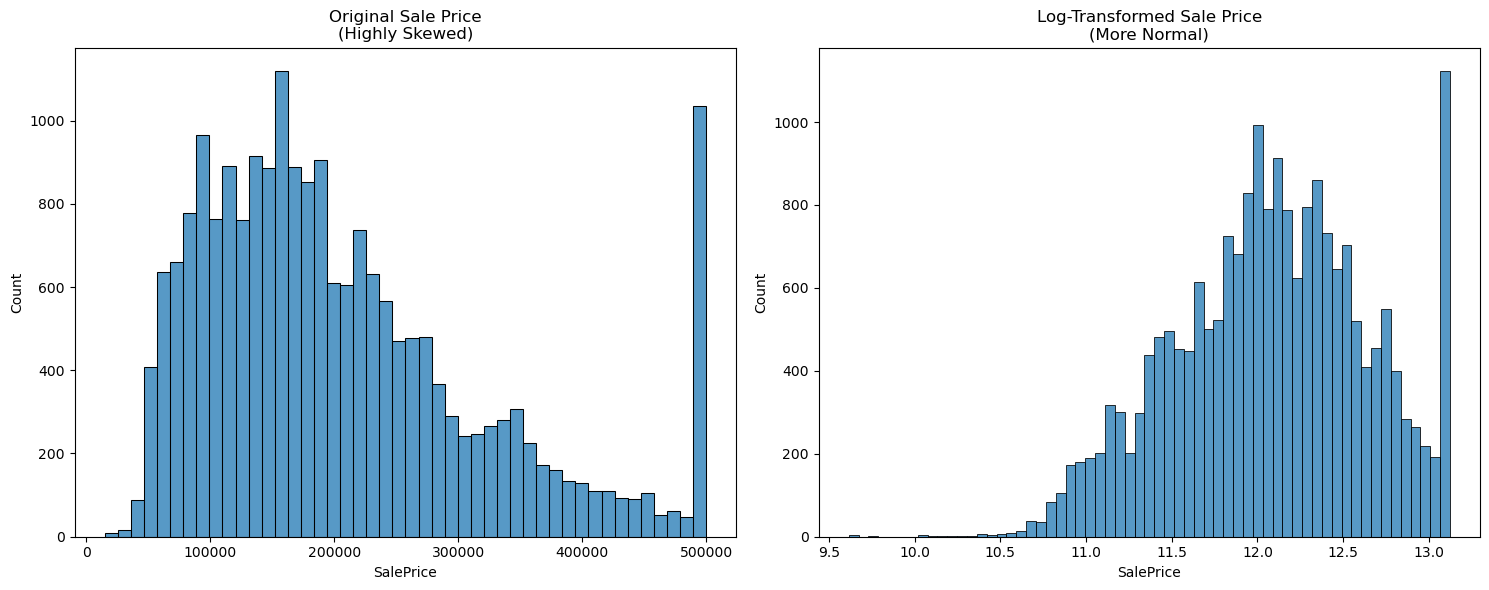

In [5]:
# (a) Price distribution

plt.figure(figsize=(15,6))

# plotting original
plt.subplot(1,2,1)
sns.histplot(df['SalePrice'])
#plt.xlim(0,500)
plt.title('Original Sale Price\n(Highly Skewed)')

# plotting transformed
plt.subplot(1,2,2)
sns.histplot(np.log1p(df['SalePrice']))
plt.title('Log-Transformed Sale Price\n(More Normal)')

plt.tight_layout()
plt.show()


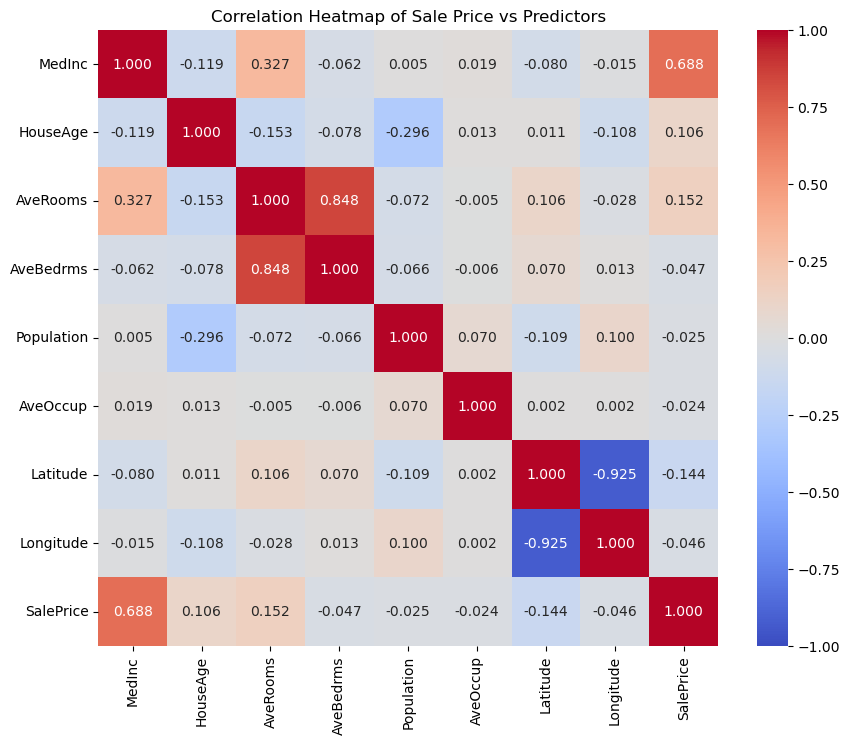


Linear Correlation with Sale Price:
SalePrice     1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: SalePrice, dtype: float64

Top 3 correlations: MedInc, AveRooms, HouseAge


In [42]:
# (b) Correlation heatmap

# 1. Compute correlation matrix including the target
corr_matrix = df.corr()

# 2. Render the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Sale Price vs Predictors')
plt.show()

# 3. Print exact correlation vector sorted to find the strongest signal
print("\nLinear Correlation with Sale Price:")
print(corr_matrix['SalePrice'].sort_values(ascending=False))
print()
top3 = corr_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False).head(3)
print(f"Top 3 correlations: {', '.join(top3.index.tolist())}")


## Q2 — Ridge vs Lasso

In [25]:
# Separate features and target using log transform
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('SalePrice')

X = df[numeric_features]
y_log = np.log1p(df['SalePrice'])


X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=420
)

# Cap extreme feature outliers at the 99th percentile
outlier_features = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']

for col in outlier_features:
    upper_limit = X_train[col].quantile(0.99)  # fit on train only
    X_train[col] = X_train[col].clip(upper=upper_limit)
    X_test[col] = X_test[col].clip(upper=upper_limit)  # apply train threshold to test

price_cap = y_train_log.quantile(0.99)
mask = y_train_log <= price_cap
X_train = X_train[mask]
y_train_log = y_train_log[mask]

print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')
print(f"Train feature matrix shape: {X_train.shape}")
print(f"Test feature matrix shape:  {X_test.shape}")
print(f'Train median: {y_train_log.median():.3f}')
print(f'Test  median: {y_test_log.median():.3f}') 

Train size: 16,512  |  Test size: 4,128
Train feature matrix shape: (16512, 8)
Test feature matrix shape:  (4128, 8)
Train median: 12.096
Test  median: 12.108


In [26]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, LogisticRegression
from sklearn.metrics import root_mean_squared_error

# 1. Properly scale our features first to ensure fair penalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 2. Automatically discover optimal alphas via cross-validation
alphas_to_test = np.logspace(-4, 2, 100)
ridge_cv = RidgeCV(alphas=alphas_to_test, cv=5).fit(X_train_scaled, y_train_log)
lasso_cv = LassoCV(alphas=alphas_to_test, cv=5, random_state=420).fit(X_train_scaled, y_train_log)

print(f"Optimal Ridge Alpha: {ridge_cv.alpha_:.4f}")
print(f"Optimal Lasso Alpha: {lasso_cv.alpha_:.4f}\n")

# 3. Fit all three models side-by-side using optimal parameters
lr = LinearRegression().fit(X_train_scaled, y_train_log)
ridge = Ridge(alpha=ridge_cv.alpha_, random_state=420).fit(X_train_scaled, y_train_log)
lasso = Lasso(alpha=lasso_cv.alpha_, random_state=420).fit(X_train_scaled, y_train_log)

# 4. Aggregate into a clean summary table to check the shrinkage effect
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear Reg': lr.coef_,
    'Ridge (L2)': ridge.coef_,
    'Lasso (L1)': lasso.coef_
})

print("--- REGULARIZATION EFFECTS REVEALED ---")
print(coef_df.to_string(index=False, formatters={
    'Linear Reg': '{:+.4f}'.format,
    'Ridge (L2)': '{:+.4f}'.format,
    'Lasso (L1)': '{:+.4f}'.format
}))
print()

# 5. Track zeroed out coefficients
n_zero_ridge = (ridge.coef_ == 0).sum()
print(f'Ridge (L2) zeroed out {n_zero_ridge} of {len(ridge.coef_)} features')
n_zero_lasso = (lasso.coef_ == 0).sum()
print(f'Lasso (L1) zeroed out {n_zero_lasso} of {len(lasso.coef_)} features')
print()

# 6. Evaluate and compare performance in true dollar amounts
models = {'Linear Regression': lr, 'Ridge': ridge, 'Lasso': lasso}
print("--- MODEL PERFORMANCE COMPARISON (TEST RMSE) ---")
for name, model in models.items():
    preds_log = model.predict(X_test_scaled)
    preds_dollars = np.expm1(preds_log)
    y_test_dollars = np.expm1(y_test_log)
    rmse = root_mean_squared_error(y_test_dollars, preds_dollars)
    print(f"{name:<20}: ${rmse:,.2f}")

Optimal Ridge Alpha: 0.0001
Optimal Lasso Alpha: 0.0001

--- REGULARIZATION EFFECTS REVEALED ---
   Feature Linear Reg Ridge (L2) Lasso (L1)
    MedInc    +0.3496    +0.3496    +0.3493
  HouseAge    +0.0428    +0.0428    +0.0428
  AveRooms    -0.0443    -0.0443    -0.0439
 AveBedrms    +0.0546    +0.0546    +0.0541
Population    +0.0373    +0.0373    +0.0372
  AveOccup    -0.1318    -0.1318    -0.1317
  Latitude    -0.6058    -0.6058    -0.6044
 Longitude    -0.5473    -0.5473    -0.5459

Ridge (L2) zeroed out 0 of 8 features
Lasso (L1) zeroed out 0 of 8 features

--- MODEL PERFORMANCE COMPARISON (TEST RMSE) ---
Linear Regression   : $76,984.18
Ridge               : $76,984.18
Lasso               : $76,971.74


*** Key takeaways:

1/ Lasso zeroed out 0 features at the optimal alpha, suggesting no feature is redundant enough to eliminate at this regularization strength, though 
a higher alpha would force sparsity.

2/ Geographic Distortion: Latitude and Longitude maintain the largest absolute magnitudes. Because linear models treat geography as a flat grid, they struggle to natively capture localized, non-linear premium zones like coastal clusters.

3/ Multicollinearity Conflict: AveRooms (negative) and AveBedrms (positive) display opposing signs. This contradiction occurs because they are highly correlated metrics tracking similar structural information, which destabilizes the linear coefficients.

4/ All three linear models perform equivalently, suggesting the dataset is clean enough that regularization provides no meaningful benefit over OLS

## Q3 — Gradient Boosting Regressor

In [27]:
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Initialize and fit the Gradient Boosting model
# No feature scaling is needed for tree-based models, so we use raw X_train
gbr = HistGradientBoostingRegressor(
    max_iter=150,        # Number of boosting rounds
    learning_rate=0.1,   # Step size shrinkage
    max_depth=5,         # Limit tree depth to control overfitting
    random_state=420
)
gbr.fit(X_train, y_train_log)

# 2. Predict and convert back to true dollar amounts
gbr_preds_log = gbr.predict(X_test)
gbr_preds_dollars = np.expm1(gbr_preds_log)
y_test_dollars = np.expm1(y_test_log)

# 3. Calculate final Test RMSE
gbr_rmse = root_mean_squared_error(y_test_dollars, gbr_preds_dollars)

# 4. Print updated comparison leaderboard
print("--- UPDATED PERFORMANCE LEADERBOARD (TEST RMSE) ---")
lr_rmse = root_mean_squared_error(y_test_dollars, np.expm1(lr.predict(X_test_scaled)))
print(f"Linear Regression      : ${lr_rmse:,.2f}")
print(f"Gradient Boosting Tree : ${gbr_rmse:,.2f}")
print(f"Absolute Drop in Error : ${lr_rmse - gbr_rmse:,.2f}")

--- UPDATED PERFORMANCE LEADERBOARD (TEST RMSE) ---
Linear Regression      : $76,984.18
Gradient Boosting Tree : $49,074.51
Absolute Drop in Error : $27,909.67


*** Key Performance Insights

1/ Non-Linear Dominance: The tree model successfully captures localized real estate values. By repeatedly splitting Latitude and Longitude coordinates into spatial bounding boxes, it automatically isolates high-value coastal regions and major urban hubs without requiring manual geographic mapping.

2/ Resilience to Outliers: Decision trees split features based on value ordering rather than mathematical magnitudes. Because of this structural trait, extreme feature anomalies—such as the maximum AveRooms value of 141.9—fail to skew or corrupt the tree branches the way they do with linear coefficients.

## Q4 — Residual Analysis

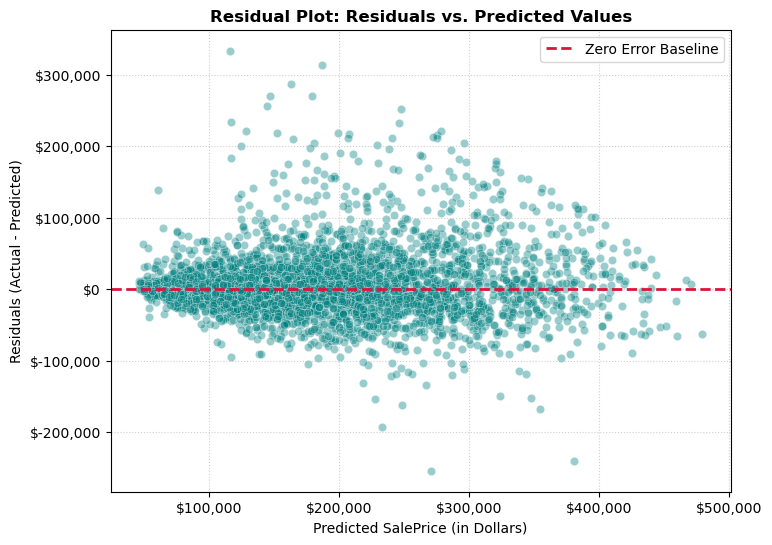

In [19]:
# Calculate residuals (Actual minus Predicted)
residuals = y_test_dollars - gbr_preds_dollars

plt.figure(figsize=(8, 6))

# X-axis must be the Predicted values; Y-axis must be the Residuals
sns.scatterplot(x=gbr_preds_dollars, y=residuals, alpha=0.4, color='teal', edgecolor='w')

# Add a horizontal line at y=0 to evaluate the baseline error spread
plt.axhline(0, color='crimson', linestyle='--', linewidth=2, label='Zero Error Baseline')

plt.title('Residual Plot: Residuals vs. Predicted Values', fontweight='bold')
plt.xlabel('Predicted SalePrice (in Dollars)') 
plt.ylabel('Residuals (Actual - Predicted)')

# Optional formatting to clean up raw scientific notation on large prices
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"${y:,.0f}"))

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

*** Key Takeaways from the plot:

1/ Clean Error Distribution: The data points form a dense, healthy cloud centered symmetrically around the crimson zero-error baseline, confirming that predictions are structurally unbiased.

2/ Tight Error Boundaries: The vast majority of residuals are tightly clustered within a stable ±$100,000 band, demonstrating strong and consistent predictive accuracy across most price tiers.

3/ Mild Variance Scaling: The vertical spread of the cloud slightly expands for properties predicted between $200,000 and $350,000, indicating that model variance increases slightly as home values go up.

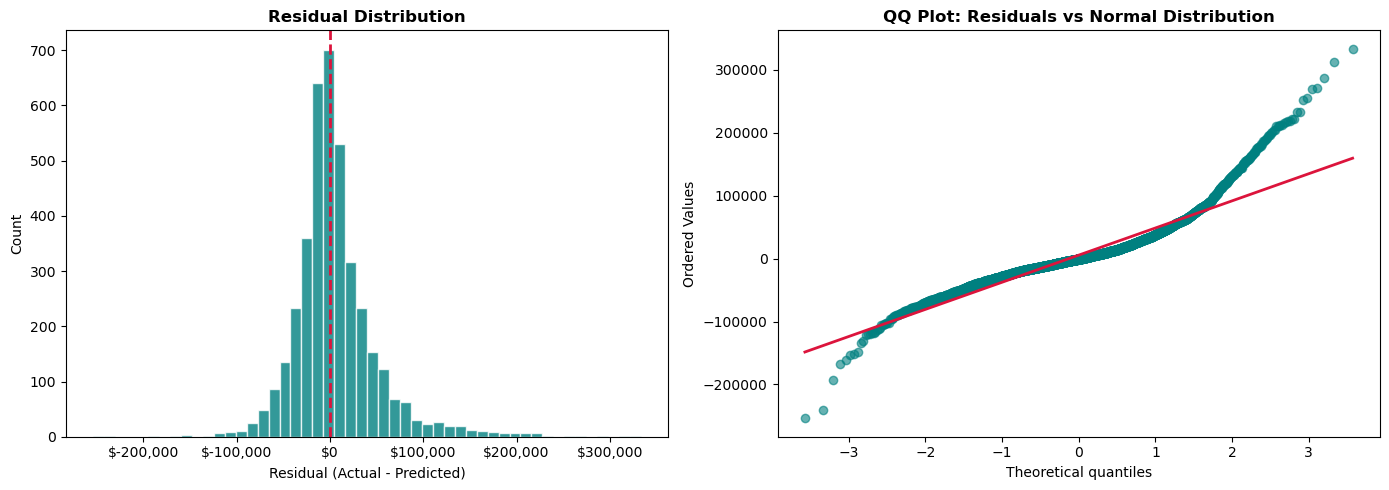

In [28]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Residual distribution
axes[0].hist(residuals, bins=50, color='teal', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='crimson', linestyle='--', linewidth=2)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Count')

# Right: QQ plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot: Residuals vs Normal Distribution', fontweight='bold')
axes[1].get_lines()[0].set(color='teal', alpha=0.6)   # scatter points
axes[1].get_lines()[1].set(color='crimson', linewidth=2)  # reference line

plt.tight_layout()
plt.show()

*** QQ Plot Takeaways:

1/ Central Normality: Residuals track the reference line closely between the -1 and +1 theoretical quantile range, confirming well-behaved errors in the mid-price tier.

2/ Heavy Upper Tail: Points deviate above the line at the high end, indicating the model underpredicts high-value properties, consistent with sparse training data at the luxury price tier.

3/ Log Transform Validation: The near-normal residual shape confirms that log-transforming SalePrice was the correct preprocessing decision.

## Q5 — Feature Importance & Business Framing

In [20]:
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(gbr, X_test, y_test_log, n_repeats=10, random_state=420)
perm_df = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': perm_imp.importances_mean,
    'Std':        perm_imp.importances_std
}).sort_values('Importance', ascending=False)
print(perm_df.head(10))

# Features with near-zero permutation importance can be dropped safely

      Feature  Importance       Std
6    Latitude    1.256793  0.024539
7   Longitude    0.996623  0.015674
0      MedInc    0.354919  0.005856
5    AveOccup    0.112026  0.003184
2    AveRooms    0.045631  0.002392
1    HouseAge    0.024725  0.001613
3   AveBedrms    0.009333  0.000698
4  Population    0.005698  0.000436


*** Key Takeaway Insights:

1/ Geography Reigns Supreme: Latitude and Longitude are the absolute dominant features, vastly eclipsing income. This confirms tree models excel at splitting raw coordinates to isolate premium coastal clusters, bypassing the linear grid limitations.

2/ Low-Impact Redundancy: Population and AveBedrms hold near-zero importance scores. These features can be dropped entirely to streamline our data pipeline with virtually no loss in model accuracy.

In [41]:
# Dynamically compute importance share for business framing
total_importance = perm_df['Importance'].clip(lower=0).sum()

geo_features = ['Latitude', 'Longitude']
demo_features = ['MedInc', 'AveOccup']
struct_features = ['AveRooms', 'HouseAge']
low_impact_features = ['Population', 'AveBedrms']

def pct_share(features):
    mask = perm_df['Feature'].isin(features)
    return perm_df.loc[mask, 'Importance'].clip(lower=0).sum() / total_importance * 100

geo_pct    = pct_share(geo_features)
demo_pct   = pct_share(demo_features)
struct_pct = pct_share(struct_features)

low_impact = perm_df[perm_df['Feature'].isin(low_impact_features)][['Feature','Importance']]

print("*** Business Framing & Highlights")
print()
print(f"1/ Location is the Primary Value Driver: Spatial geography "
      f"(Latitude/Longitude) dictates {geo_pct:.1f}% of the model's predictive "
      f"weight, confirming that micro-market neighborhood clustering is far more "
      f"critical than individual house structures.")
print()
print(f"2/ Demographics Outweigh Structural Size: Household wealth and density "
      f"(MedInc, AveOccup) carry {demo_pct:.1f}% predictive weight vs "
      f"{struct_pct:.1f}% for structural attributes (AveRooms, HouseAge).")
print()
print(f"3/ Streamlined Data Overhead: Low-impact features flagged for review:")
print(low_impact.to_string(index=False))
print("   Confirm with cross-validated RMSE before dropping.")

*** Business Framing & Highlights

1/ Location is the Primary Value Driver: Spatial geography (Latitude/Longitude) dictates 80.3% of the model's predictive weight, confirming that micro-market neighborhood clustering is far more critical than individual house structures.

2/ Demographics Outweigh Structural Size: Household wealth and density (MedInc, AveOccup) carry 16.6% predictive weight vs 2.5% for structural attributes (AveRooms, HouseAge).

3/ Streamlined Data Overhead: Low-impact features flagged for review:
   Feature  Importance
 AveBedrms    0.009333
Population    0.005698
   Confirm with cross-validated RMSE before dropping.
